# Corvus corone Biodiversity Prediction

## Introduction

Citizen science biodiversity observations can help researchers monitor species and biodiversity patterns.

However, these observations may contain biases related to location, season and observer activity.

The goal of this project is to predict whether Corvus corone is observed using location, time and sampling-effort variables.

# Data Loading

We loaded the GBIF biodiversity dataset for Corvus corone.

In [8]:
import pandas as pd
import zipfile
from pathlib import Path

PROJECT_ROOT = Path("..")

RAW_DATA = PROJECT_ROOT / "data" / "raw" / "Corvus corone.csv.zip"

with zipfile.ZipFile(RAW_DATA, "r") as z:
    csv_name = z.namelist()[0]

    with z.open(csv_name) as f:
        df = pd.read_csv(f)

df.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30456\4113345672.py:13: DtypeWarning: Columns (0: Corvus corone) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Corvus corone
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,25.0,25,1
2,50.75,5.65,2010-01-03,3.0,3,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


# Data Understanding

The dataset contains:
- date
- latitude
- longitude
- observation counts

In [9]:
df.shape

(12558786, 6)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Corvus corone              object 
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 574.9+ MB


In [11]:
df.isnull().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Corvus corone                0
dtype: int64

# Data Cleaning

We removed duplicates, converted dates and handled missing values.

In [12]:
df = df.drop_duplicates()

df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")

numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Feature Engineering

We created time-based features and a binary target variable.

In [14]:
# Convert eventDate to datetime
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")

# Create time-based features
df["month"] = df["eventDate"].dt.month
df["year"] = df["eventDate"].dt.year
df["day_of_week"] = df["eventDate"].dt.dayofweek

# Convert target column to numeric
df["Corvus corone"] = pd.to_numeric(df["Corvus corone"], errors="coerce").fillna(0)

# Create binary target
df["target_class"] = (df["Corvus corone"] > 0).astype(int)

df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Corvus corone,month,year,day_of_week,target_class
0,50.75,5.65,2010-01-01,0.0,0,0.0,1,2010,4,0
1,50.75,5.65,2010-01-02,25.0,25,1.0,1,2010,5,1
2,50.75,5.65,2010-01-03,3.0,3,0.0,1,2010,6,0
3,50.75,5.65,2010-01-04,0.0,0,0.0,1,2010,0,0
4,50.75,5.65,2010-01-05,0.0,0,0.0,1,2010,1,0


In [15]:
df["target_class"].value_counts()

target_class
0    11946959
1      611827
Name: count, dtype: int64

# Exploratory Data Analysis

We explored seasonal patterns and class imbalance.

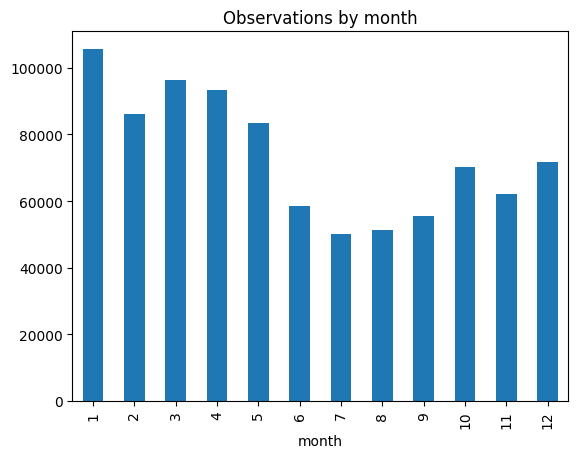

In [16]:
import matplotlib.pyplot as plt

monthly = df.groupby("month")["Corvus corone"].sum()

monthly.plot(kind="bar")
plt.title("Observations by month")
plt.show()

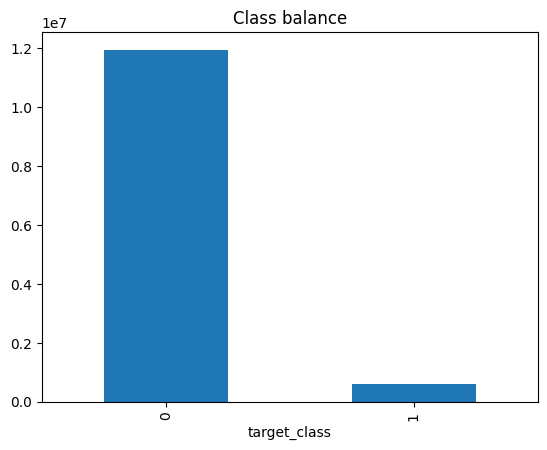

In [17]:
df["target_class"].value_counts().plot(kind="bar")
plt.title("Class balance")
plt.show()

# Modeling

We used a Random Forest Classifier.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "decimalLatitude",
    "decimalLongitude",
    "month",
    "year"
]

X = df[features]
y = df["target_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Evaluation

We evaluated the model using precision, recall and F1-score.

In [ ]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98   2389445
           1       0.61      0.12      0.20    122313

    accuracy                           0.95   2511758
   macro avg       0.78      0.56      0.59   2511758
weighted avg       0.94      0.95      0.94   2511758

